# Hypothesis 1: What drives taxi trip volume across NYC zones?

This analysis explores how weather conditions and POI density influence taxi demand using a zone × date dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/processed/final/zone_date_master_2025.parquet")

# Filter to 2025
df = df[df["date"] >= pd.to_datetime("2025-01-01").date()]

df.head()

,date,taxi_zone_id,fare_amount_yellow,total_amount_yellow,trip_distance_yellow,trips_pickup_yellow,poi_count_total,poi_name_examples,poi_count_other,tmax,tmin,prcp,awnd,snow,temp_avg,rainy_day,heavy_rain_day,pleasant_temp_day
23,2025-01-01,1,69.569524,78.450000,0.404762,21,NaN,NaN,NaN,10.6,3.9,0.0,3.7,0.0,7.25,0.0,0.0,0.0
24,2025-01-01,3,6.975556,8.142222,4.108889,9,46.0,ALLERTON PLAYGROUND; AMBER COURT OF PELHAM GAR...,46.0,10.6,3.9,0.0,3.7,0.0,7.25,0.0,0.0,0.0
25,2025-01-01,4,14.183978,21.081264,3.101041,269,130.0,10 STREET PEDESTRIAN; 11 BC SERENITY GARDEN; 5...,130.0,10.6,3.9,0.0,3.7,0.0,7.25,0.0,0.0,0.0
26,2025-01-01,5,-6.400000,-4.900000,16.190000,1,8.0,ARDEN HEIGHTS WOODS; ARDEN WOODS; CARLTON PARK...,8.0,10.6,3.9,0.0,3.7,0.0,7.25,0.0,0.0,0.0
27,2025-01-01,6,0.010000,18.360000,4.145000,2,68.0,AMERICAN LEGION POST 1544; ANGELS CIRCLE 9 / 1...,68.0,10.6,3.9,0.0,3.7,0.0,7.25,0.0,0.0,0.0


### Data Granularity

The dataset is structured at a zone × date level, where each row represents aggregated taxi demand for a specific taxi zone on a given day.

## Data Sanity Check

We verify that key variables (weather features) do not contain missing values.

In [2]:
df[["temp_avg", "rainy_day"]].isna().sum()

temp_avg     0
rainy_day    0
dtype: int64

In [3]:
rain_effect = df.groupby("rainy_day")["trips_pickup_yellow"].mean()
rain_effect

rainy_day
0.0    540.128635
1.0    570.918725
Name: trips_pickup_yellow, dtype: float64

## Weather Analysis: Impact of Rain and Temperature

#### Rainy Day

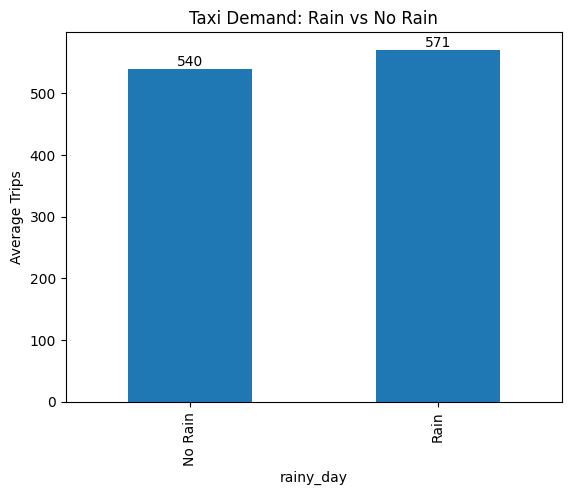

In [13]:
ax= rain_effect.plot(kind="bar")
plt.xticks([0, 1], ["No Rain", "Rain"])
plt.title("Taxi Demand: Rain vs No Rain")
plt.ylabel("Average Trips")

# Add values on bars
for i, v in enumerate(rain_effect):
    ax.text(i, v + 5, f"{v:.0f}", ha='center')

plt.show()

Taxi demand increases on rainy days, indicating higher reliance on taxis during adverse weather conditions.

#### Heavy Rainy Day

In [5]:
df.groupby("heavy_rain_day")["trips_pickup_yellow"].mean()

heavy_rain_day
0.0    546.338013
1.0    586.769064
Name: trips_pickup_yellow, dtype: float64

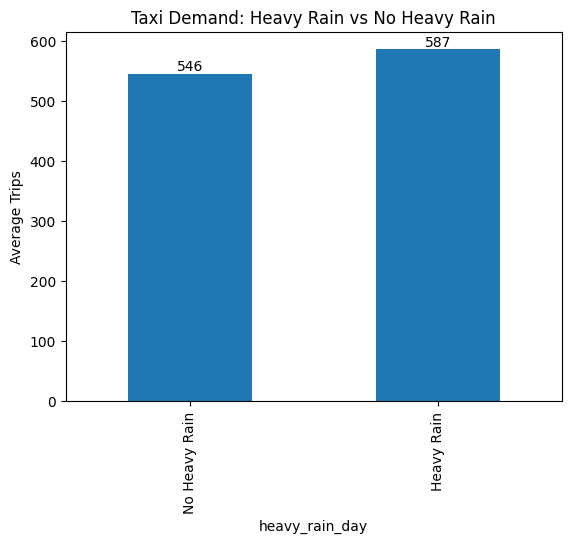

In [ ]:
heavy_rain_effect = df.groupby("heavy_rain_day")["trips_pickup_yellow"].mean()

ax = heavy_rain_effect.plot(kind="bar")

plt.xticks([0, 1], ["No Heavy Rain", "Heavy Rain"])
plt.title("Taxi Demand: Heavy Rain vs No Heavy Rain")
plt.ylabel("Average Trips")

# Add values on bars
for i, v in enumerate(heavy_rain_effect):
    ax.text(i, v + 5, f"{v:.0f}", ha='center')

plt.show()

Heavy rainfall further amplifies taxi demand compared to light or no rain.

## Effect of temperature on taxi demand

#### Pleasant day

In [14]:
df.groupby("pleasant_temp_day")["trips_pickup_yellow"].mean()

pleasant_temp_day
0.0    549.139397
1.0    551.963582
Name: trips_pickup_yellow, dtype: float64

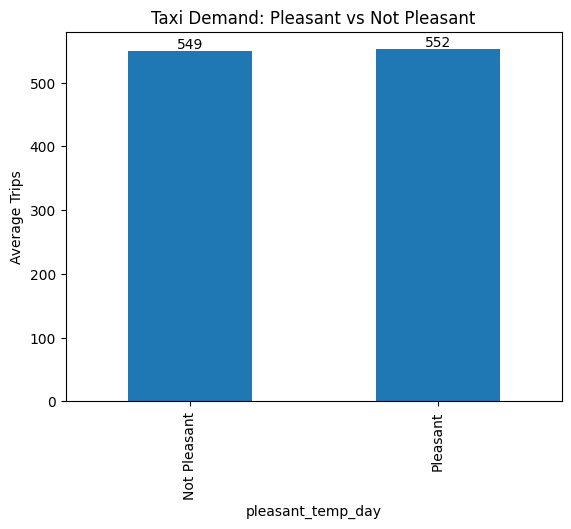

In [16]:
pleasant_effect = df.groupby("pleasant_temp_day")["trips_pickup_yellow"].mean()

ax = pleasant_effect.plot(kind="bar")
plt.xticks([0, 1], ["Not Pleasant", "Pleasant"])
plt.title("Taxi Demand: Pleasant vs Not Pleasant")
plt.ylabel("Average Trips")

# Add values on bars
for i, v in enumerate(pleasant_effect):
    ax.text(i, v + 5, f"{v:.0f}", ha='center')
plt.show()

Pleasant temperature has minimal impact on taxi demand.

#### Taxi and temperature correlation

In [17]:
df[["trips_pickup_yellow", "temp_avg"]].corr()

,trips_pickup_yellow,temp_avg
trips_pickup_yellow,1.00000,0.00398
temp_avg,0.00398,1.00000


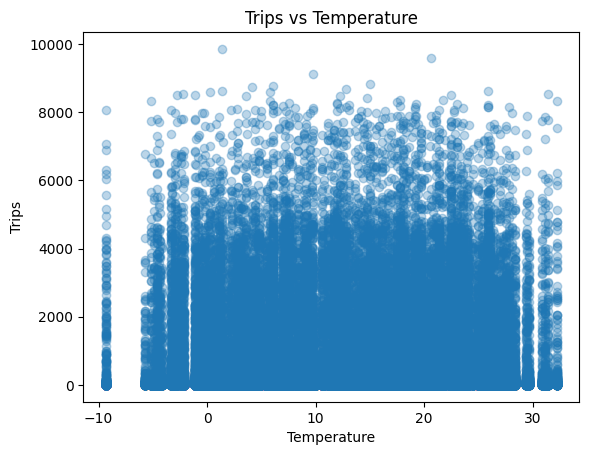

In [18]:
plt.scatter(df["temp_avg"], df["trips_pickup_yellow"], alpha=0.3)
plt.xlabel("Temperature")
plt.ylabel("Trips")
plt.title("Trips vs Temperature")
plt.show()

There is no clear relationship between temperature and taxi demand.

## Summary of Weather Analysis

To evaluate the influence of temporal factors on taxi demand, we analyze weather variables including rainfall, heavy rainfall, and temperature.

The results show a clear increase in average taxi trips on rainy days compared to non-rainy days. This effect is further amplified during periods of heavy rainfall, indicating that adverse weather conditions significantly increase reliance on taxis.

In contrast, temperature exhibits negligible correlation with taxi demand. The scatter plot of trips versus temperature shows no clear trend, suggesting that temperature alone is not a strong driver of demand.

### Key Insights

- Taxi demand increases on rainy days and further increases during heavy rainfall.
- Temperature shows negligible correlation with taxi demand, indicating it is not a significant driver compared to precipitation.
- Weather effects are primarily driven by precipitation rather than temperature.

### Interpretation

These findings suggest that short-term weather disruptions, particularly rainfall, play a significant role in shaping mobility behavior. Users are more likely to substitute walking or public transit with taxis during unfavorable weather conditions.

### Conclusion

Weather, especially rainfall, is a strong temporal driver of taxi demand, whereas temperature does not significantly influence demand patterns.

## City-Level Analysis (Temporal Trends)

We aggregate total taxi trips per day to analyze demand patterns over time.

In [19]:
city_df = df.groupby("date")["trips_pickup_yellow"].sum().reset_index()
city_df.head()

,date,trips_pickup_yellow
0,2025-01-01,90188
1,2025-01-02,84832
2,2025-01-03,91250
3,2025-01-04,97804
4,2025-01-05,79624


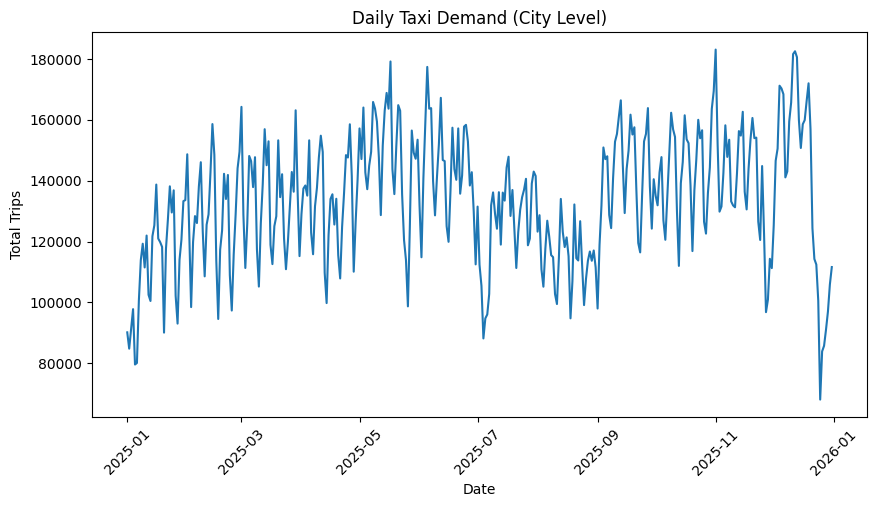

In [20]:
plt.figure(figsize=(10,5))
plt.plot(city_df["date"], city_df["trips_pickup_yellow"])
plt.xticks(rotation=45)
plt.title("Daily Taxi Demand (City Level)")
plt.ylabel("Total Trips")
plt.xlabel("Date")
plt.show()

## Summary of City-Level Analysis

To understand overall demand dynamics, taxi trips are aggregated at the city level on a daily basis.

The time-series plot shows significant day-to-day variability in total taxi demand, with no clear long-term upward or downward trend over the year. However, recurring fluctuations suggest the presence of cyclical patterns, likely driven by weekly behavioral trends such as weekday–weekend differences.

### Key Insights

- Taxi demand varies significantly across days.
- No strong long-term trend is observed over the year.
- Repeating fluctuations suggest underlying temporal cycles.

### Interpretation

The observed variability indicates that taxi demand is influenced by dynamic temporal factors beyond weather conditions. These may include weekly commuting patterns, social behavior, and special events. 

### Conclusion

City-level demand patterns highlight the importance of temporal dynamics, suggesting that short-term behavioral cycles play a key role in influencing taxi usage.

## Spatial Analysis : POI Density vs Taxi Demand

We analyze how taxi demand varies across zones based on POI density.

In [21]:
zone_df = df.groupby("taxi_zone_id").agg({
    "trips_pickup_yellow": "mean",
    "poi_count_total": "first"
}).reset_index()

In [22]:
zone_df[["trips_pickup_yellow", "poi_count_total"]].corr()

,trips_pickup_yellow,poi_count_total
trips_pickup_yellow,1.000000,0.022873
poi_count_total,0.022873,1.000000


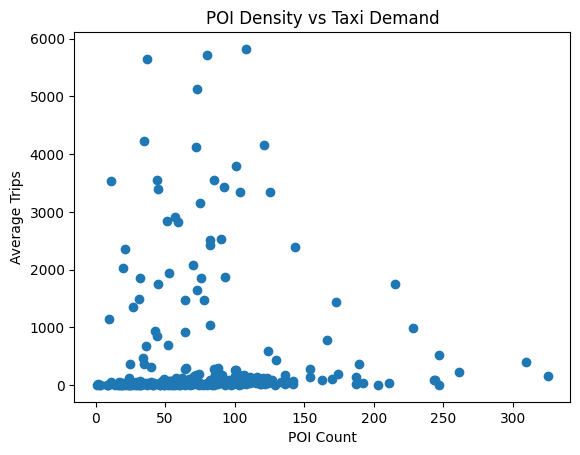

In [23]:
plt.scatter(zone_df["poi_count_total"], zone_df["trips_pickup_yellow"])
plt.xlabel("POI Count")
plt.ylabel("Average Trips")
plt.title("POI Density vs Taxi Demand")
plt.show()

## Summary of Spatial Analysis

To understand how spatial characteristics influence taxi demand, we analyze the relationship between POI (Points of Interest) density and average taxi trips across zones.

The scatter plot of POI count versus average taxi trips shows a highly dispersed pattern with no clear linear relationship. While a few zones exhibit very high taxi demand, these are limited in number and do not correspond consistently to the highest POI counts.

Most zones cluster at low to moderate POI counts with relatively low taxi demand, suggesting that simply having more POIs does not necessarily translate into higher taxi usage. Additionally, there are instances where zones with high POI counts exhibit low demand and vice versa, indicating the presence of other influencing factors.

### Key Insights

- POI density alone shows a weak relationship with taxi demand.
- A small number of zones account for disproportionately high demand, likely corresponding to key urban or transit hubs.
- The variability in demand across zones suggests that location context and type of POIs may be more important than total POI count.

### Interpretation

These findings suggest that aggregated POI counts may mask important heterogeneity across different types of locations. Not all POIs contribute equally to taxi demand, and factors such as zone importance, accessibility, and temporal dynamics likely play a more significant role.

### Conclusion

While POI density provides a spatial perspective on taxi demand, it is not a strong standalone predictor. A more granular analysis incorporating POI categories or contextual location features may yield deeper insights into demand patterns.

## Overall Findings

This analysis combines spatial and temporal perspectives to understand taxi demand across NYC zones.

- Weather, particularly rainfall, is the strongest driver of taxi demand.
- Temperature has negligible influence on demand.
- POI density shows a weak and inconsistent relationship with demand.
- Demand exhibits strong temporal variability, indicating the presence of additional behavioral patterns.

## Final Conclusion

Taxi demand is driven more by short-term temporal factors, especially weather conditions and behavioral cycles, than by static spatial features such as POI density. This suggests that dynamic context plays a more critical role in shaping urban mobility patterns.